# Imports

In [2]:
import matplotlib.pyplot as plt
import textstat
import pandas as pd
import seaborn as sns
import numpy as np
import re

from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
from models.comment import Comment
from models.gitFile import GitFile
from models.issue import Issue
from models.modifiedFiles import ModifiedFiles
from models.pullRequest import PullRequest
from models.repository import Repository
from models.testResult import TestResult
from textblob import TextBlob
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import words
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Initialisation

In [3]:
engine = create_engine('sqlite:///youtube-dlT5.db')
Session = sessionmaker(bind=engine)
session = Session()

issues = session.query(Issue).offset(7).all()
comments = session.query(Comment).filter(Comment.issueId.in_([issue.id for issue in issues])).all()

# Study

## Basic Analysis

In [4]:
title_lengths = [len(issue.title) for issue in issues]
body_lengths = [len(issue.body) for issue in issues]
comment_lengths = [len(comment.body) for comment in comments]
comment_counts = {}
for comment in comments:
    if comment.issueId in comment_counts:
        comment_counts[comment.issueId] += 1
    else:
        comment_counts[comment.issueId] = 1

### Visualisation

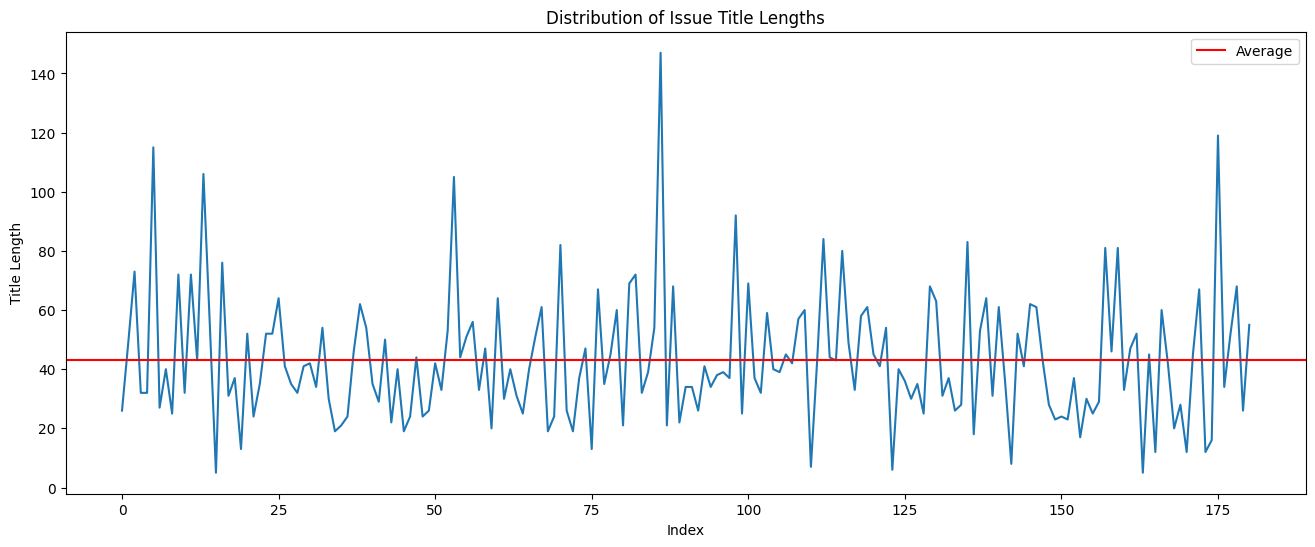

average : 43.027624309392266 characters


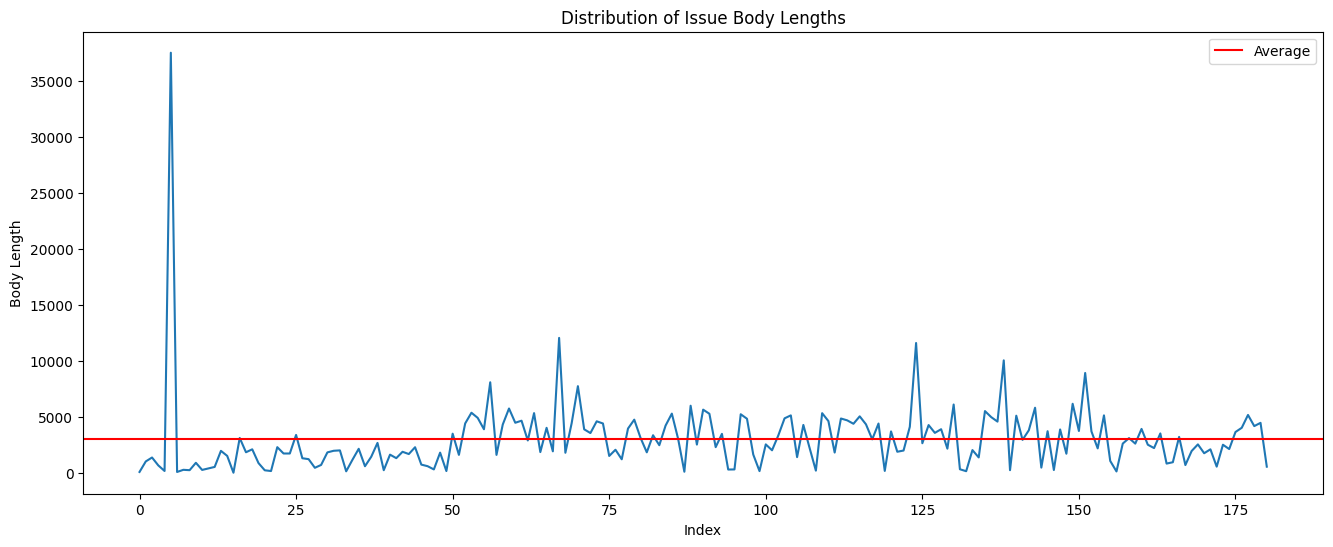

average : 3001.270718232044 characters


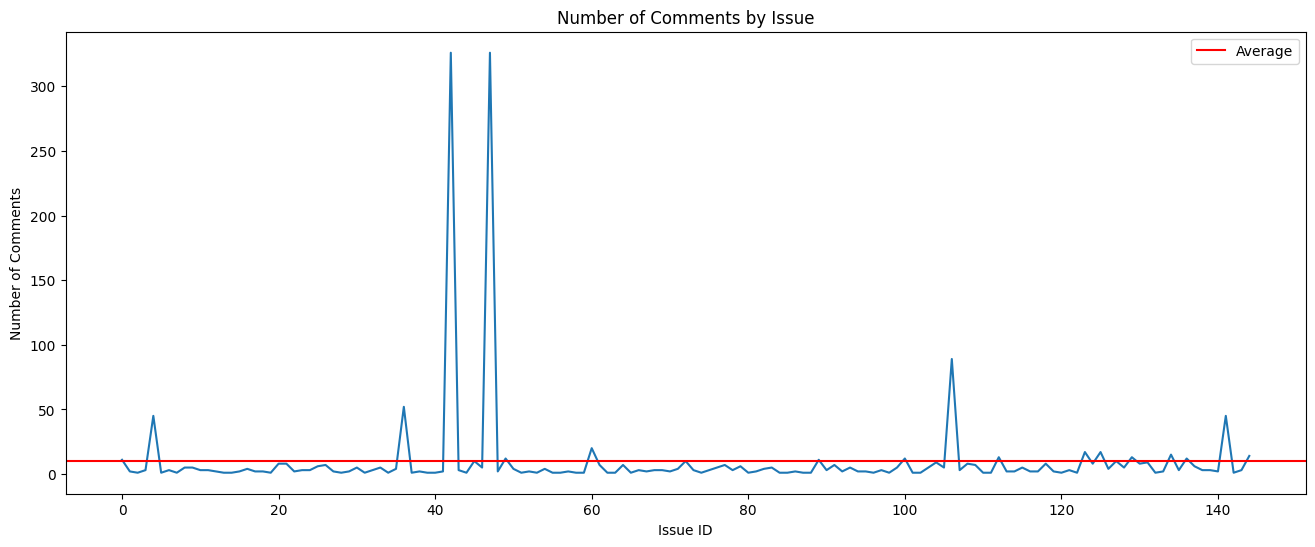

average : 10.048275862068966 comment per issue


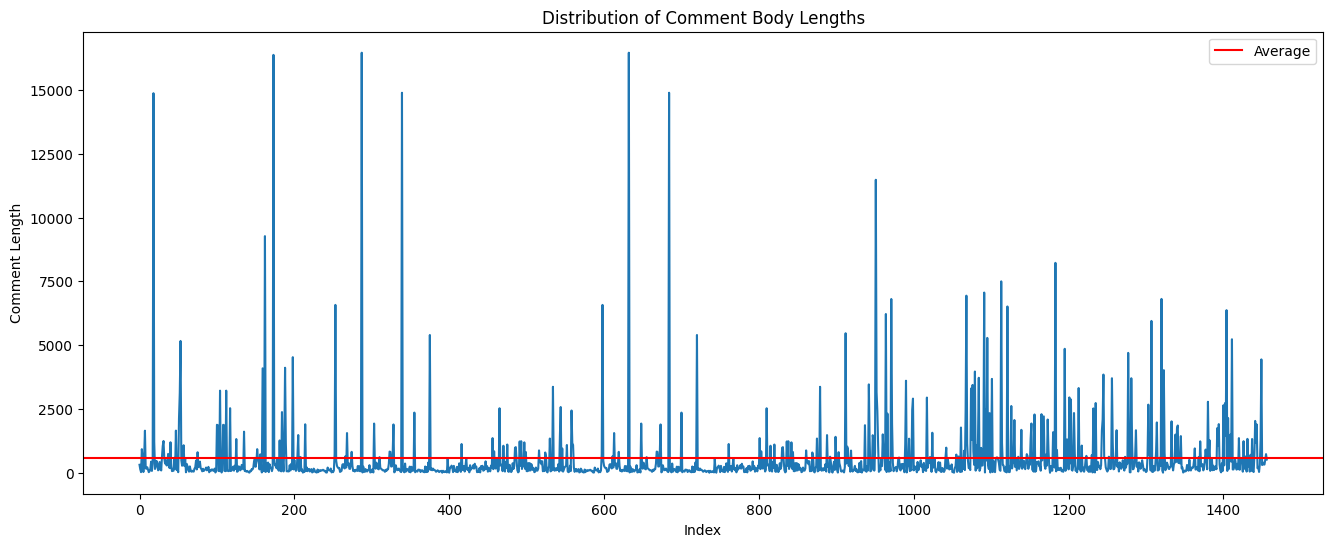

average : 562.1633493479753 characters


In [5]:
plt.figure(figsize=(16, 6))
plt.plot(title_lengths)
plt.axhline(sum(title_lengths) / len(title_lengths), color='r', linestyle='-', label='Average')
plt.title('Distribution of Issue Title Lengths')
plt.ylabel('Title Length')
plt.xlabel('Index')
plt.legend()
plt.show()

print("average : " + str(sum(title_lengths) / len(title_lengths)) + " characters")

plt.figure(figsize=(16, 6))
plt.plot(body_lengths)
plt.axhline(sum(body_lengths) / len(body_lengths), color='r', linestyle='-', label='Average')
plt.title('Distribution of Issue Body Lengths')
plt.ylabel('Body Length')
plt.xlabel('Index')
plt.legend()
plt.show()

print("average : " + str(sum(body_lengths) / len(body_lengths)) + " characters")

plt.figure(figsize=(16, 6))
plt.plot(range(len(comment_counts)), list(comment_counts.values()))
plt.xlabel('Issue ID')
plt.ylabel('Number of Comments')
plt.title('Number of Comments by Issue')
plt.axhline(sum(comment_counts.values()) / len(comment_counts), color='r', linestyle='-', label='Average')
plt.legend()
plt.show()

print("average : " + str(sum(comment_counts.values()) / len(comment_counts)) + " comment per issue")

plt.figure(figsize=(16, 6))
plt.plot(comment_lengths)
plt.axhline(sum(comment_lengths) / len(comment_lengths), color='r', linestyle='-', label='Average')
plt.title('Distribution of Comment Body Lengths')
plt.ylabel('Comment Length')
plt.xlabel('Index')
plt.legend()
plt.show()

print("average : " + str(sum(comment_lengths) / len(comment_lengths)) + " characters")

## Advanced Analysis

### Functions

In [6]:
def analyze_issue(issue_text):
    # Sentiment Analysis
    blob = TextBlob(issue_text)
    sentiment = blob.sentiment

    # Readability Scores
    flesch_kincaid = textstat.flesch_kincaid_grade(issue_text)
    gunning_fog = textstat.gunning_fog(issue_text)

    return {
        "sentiment_polarity": sentiment.polarity,
        "sentiment_subjectivity": sentiment.subjectivity,
        "flesch_kincaid": flesch_kincaid,
        "gunning_fog": gunning_fog
    }

def lexical_diversity(text):
    tokens = word_tokenize(text)
    return len(set(tokens)) / len(tokens) if tokens else 0

def avg_sentence_length(text):
    sentences = sent_tokenize(text)
    return sum(len(word_tokenize(sentence)) for sentence in sentences) / len(sentences) if sentences else 0

def count_spelling_errors(text):
    words_in_text = set(word_tokenize(text.lower()))
    english_words = set(words.words())
    return len(words_in_text - english_words)

def contains_code(text):
    code_pattern = re.compile(r'```[\s\S]*?```|`[\s\S]*?`')
    return bool(code_pattern.search(text))

# Preprocess texts for LDA
def preprocess_text(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token.isalpha()]
    return ' '.join(tokens)

### Data Process

In [7]:
analysis_results = []
for issue in issues:
    text = issue.body
    
    # Existing metrics
    blob = TextBlob(text)
    sentiment = blob.sentiment
    flesch_kincaid = textstat.flesch_kincaid_grade(text)
    gunning_fog = textstat.gunning_fog(text)
    keywords = ["reproduce", "reproduction", "describe", "description"]
    keyword_count = sum(text.lower().count(keyword) for keyword in keywords)
    
    # Additional metrics
    lex_div = lexical_diversity(text)
    avg_sent_len = avg_sentence_length(text)
    spell_errors = count_spelling_errors(text)
    code_present = contains_code(text)
    
    result = {
        "id": issue.id,
        "sentiment_polarity": sentiment.polarity,
        "sentiment_subjectivity": sentiment.subjectivity,
        "flesch_kincaid": flesch_kincaid,
        "gunning_fog": gunning_fog,
        "keyword_count": keyword_count,
        "lexical_diversity": lex_div,
        "avg_sentence_length": avg_sent_len,
        "spelling_errors": spell_errors,
        "code_present": code_present
    }
    
    analysis_results.append(result)

df = pd.DataFrame(analysis_results)

### Code present result

In [8]:
code_present_avg = sum(result['code_present'] for result in analysis_results) / len(analysis_results)
print(f"Average of code_present: {code_present_avg}")

Average of code_present: 0.7016574585635359


### Visualisation

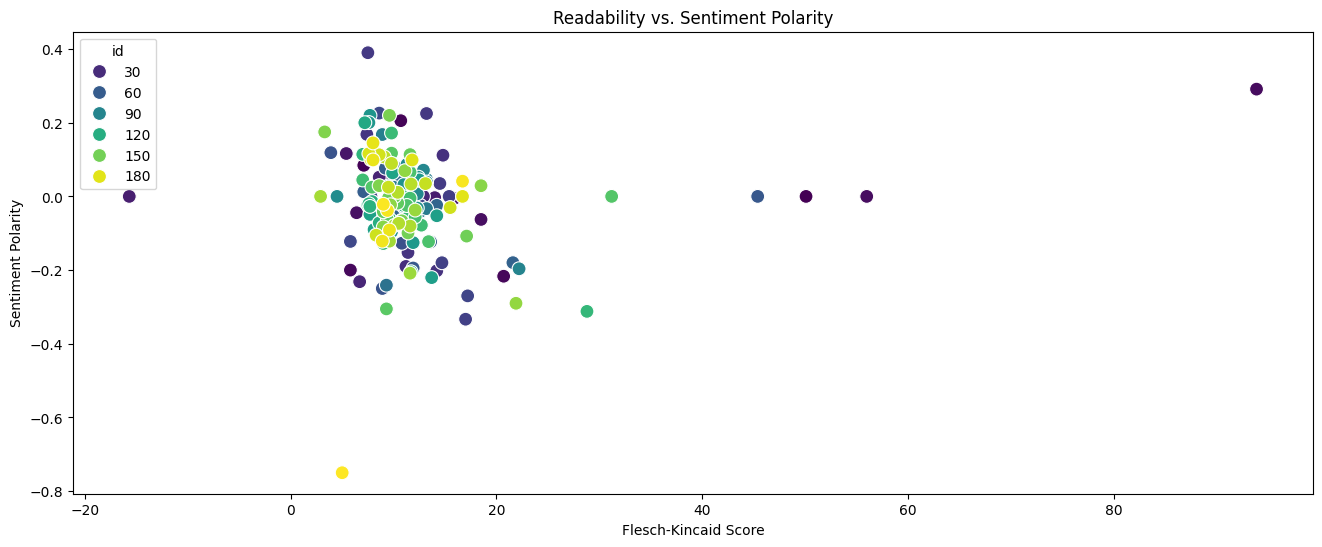

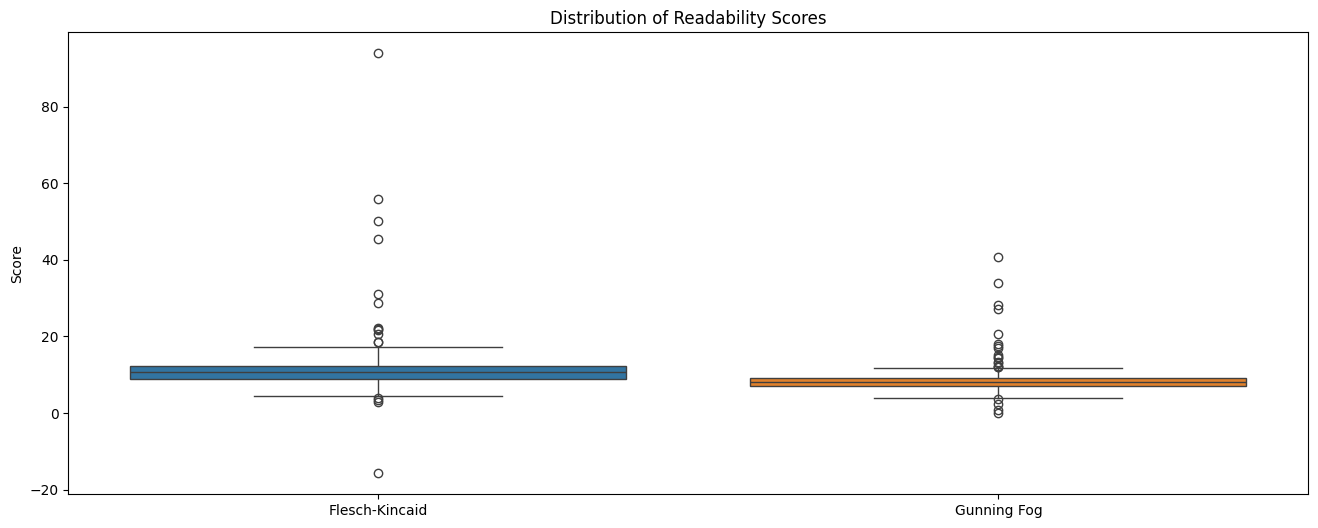

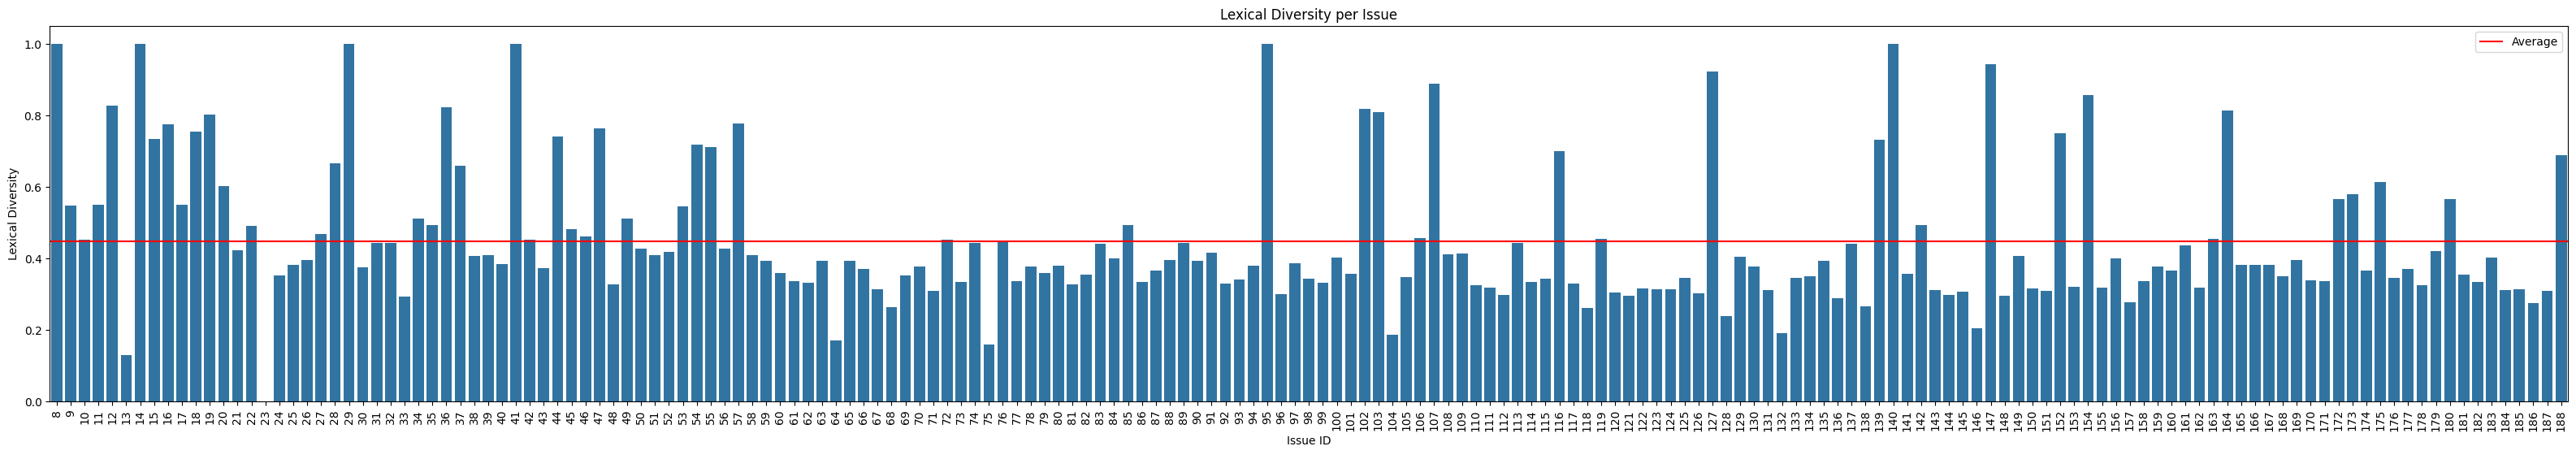

Average Lexical Diversity: 0.45


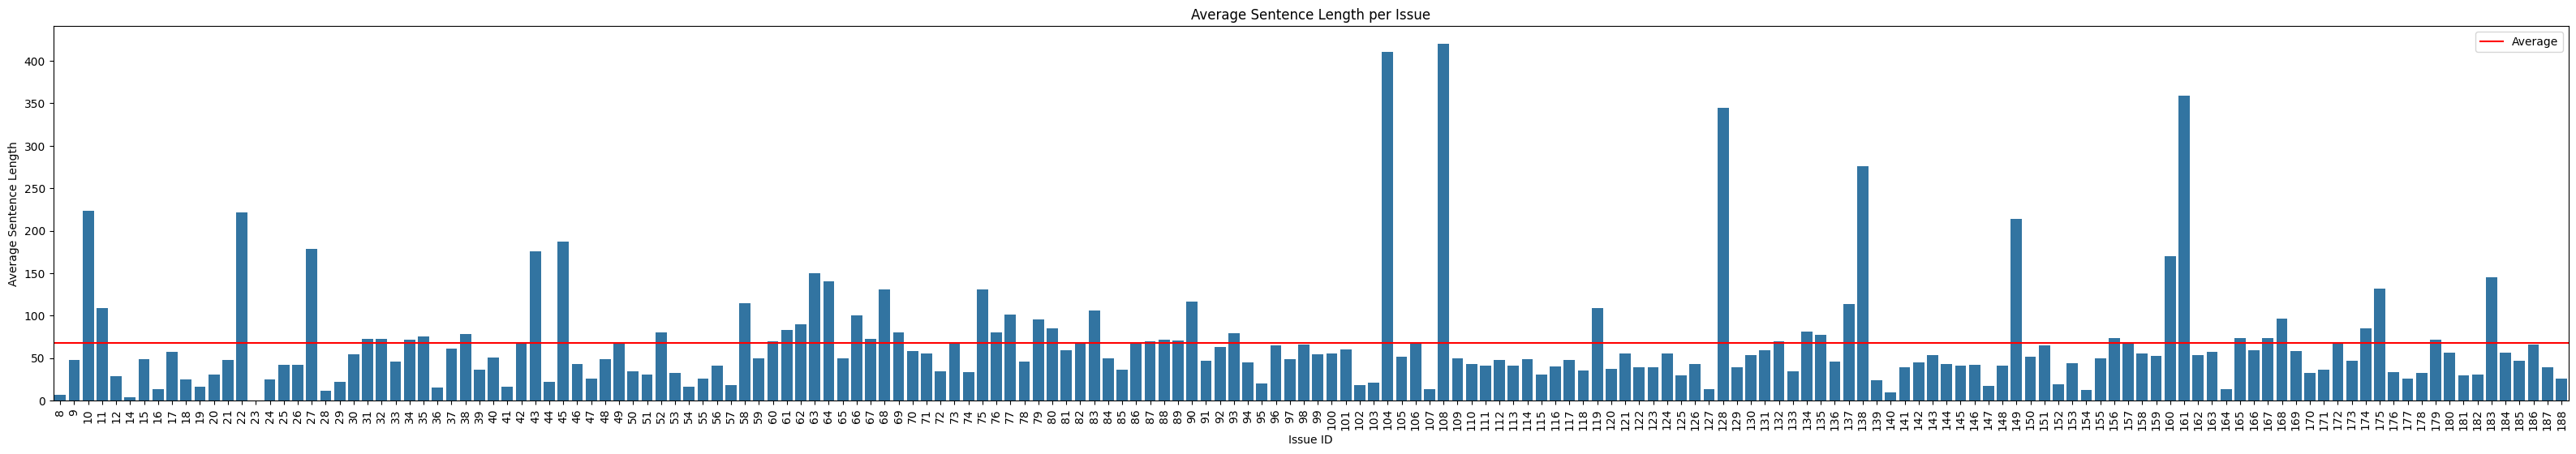

Average Sentence Length: 67.74


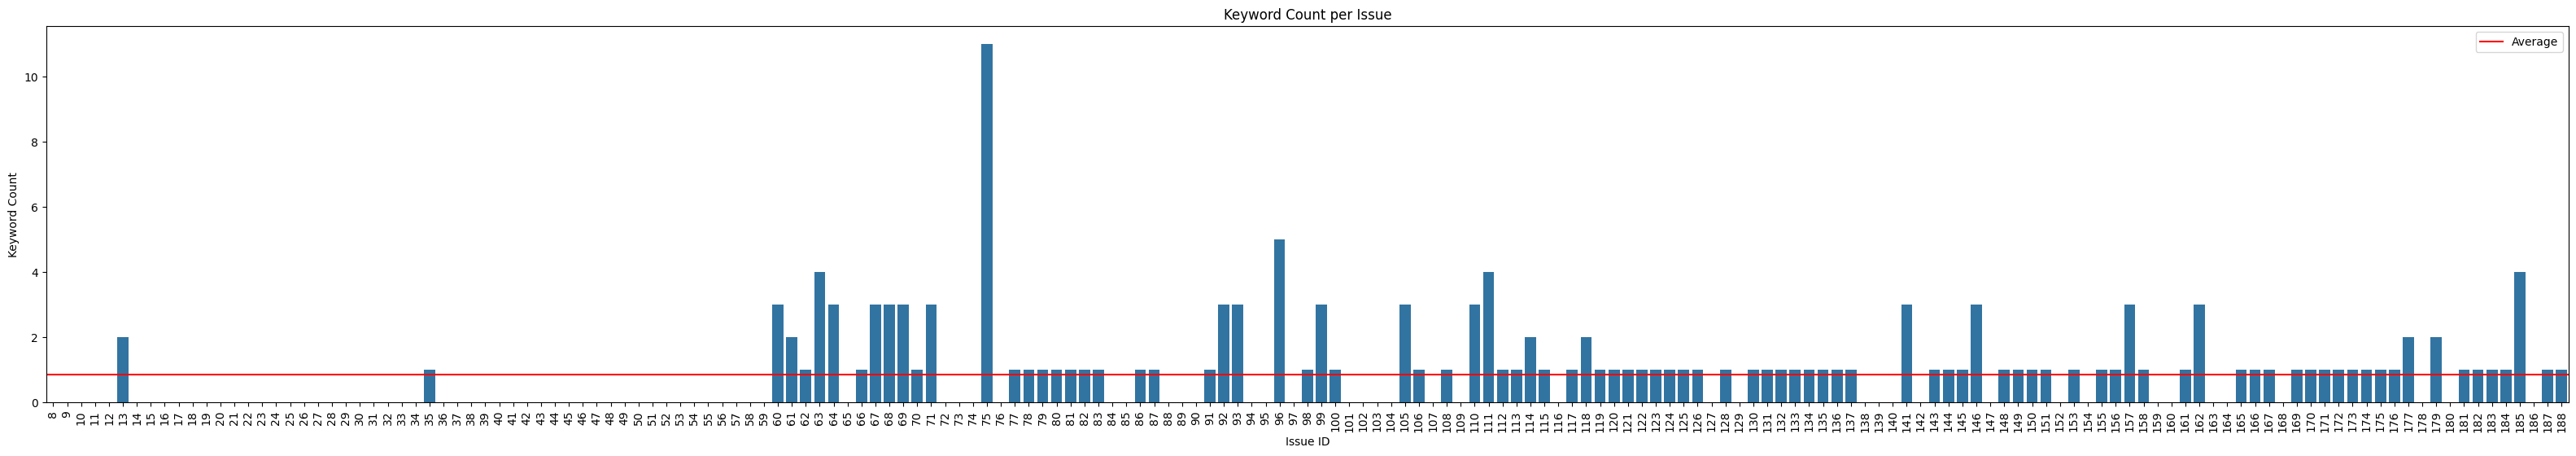

Average Keyword Count: 0.85


In [9]:
step = 15

# Scatter Plot for Readability vs. Sentiment
plt.figure(figsize=(16, 6))
sns.scatterplot(x='flesch_kincaid', y='sentiment_polarity', data=df, hue='id', palette='viridis', s=100)
plt.title('Readability vs. Sentiment Polarity')
plt.xlabel('Flesch-Kincaid Score')
plt.ylabel('Sentiment Polarity')
plt.show()

# Box Plots for Readability Scores
plt.figure(figsize=(16, 6))
sns.boxplot(data=df[['flesch_kincaid', 'gunning_fog']])
plt.title('Distribution of Readability Scores')
plt.ylabel('Score')
plt.xticks([0, 1], ['Flesch-Kincaid', 'Gunning Fog'])
plt.show()

# Lexical Diversity
plt.figure(figsize=(40, 6))
sns.barplot(x='id', y='lexical_diversity', data=df)
plt.title('Lexical Diversity per Issue')
plt.xlabel('Issue ID')
plt.ylabel('Lexical Diversity')
plt.xticks(rotation=90)
plt.axhline(y=df['lexical_diversity'].mean(), color='r', linestyle='-', label='Average')
plt.legend()
plt.show()

print(f"Average Lexical Diversity: {df['lexical_diversity'].mean():.2f}")

# Average Sentence Length
plt.figure(figsize=(40, 6))
sns.barplot(x='id', y='avg_sentence_length', data=df[df['id'] != 13])
plt.title('Average Sentence Length per Issue')
plt.xlabel('Issue ID')
plt.ylabel('Average Sentence Length')
plt.xticks(rotation=90)
plt.axhline(y=df[df['id'] != 13]['avg_sentence_length'].mean(), color='r', linestyle='-', label='Average')
plt.legend()
plt.show()

print(f"Average Sentence Length: {df[df['id'] != 13]['avg_sentence_length'].mean():.2f}")

# Plot Keyword Count
plt.figure(figsize=(40, 6))
sns.barplot(x='id', y='keyword_count', data=df)
plt.title('Keyword Count per Issue')
plt.xlabel('Issue ID')
plt.ylabel('Keyword Count')
plt.xticks(rotation=90)
plt.axhline(y=df['keyword_count'].mean(), color='r', linestyle='-', label='Average')
plt.legend()
plt.show()

print(f"Average Keyword Count: {df['keyword_count'].mean():.2f}")

### Fetch results data

In [10]:
%store -r index_divided_length
print(index_divided_length)

[0.33003300330033003, 0.6779661016949152, 2.0710059171597632, 0.9202453987730062, 0.0, 1.5384615384615385, 20.945945945945947, 0.14947683109118087, 0.27548209366391185, 0.3811944091486658, 0.0, 1.9230769230769231, -0.0946073793755913, 8.842897460018815, 0.2803738317757009, 2.3423423423423424, 0.08375209380234507, 8.166666666666666, 15.789473684210526, 77.68526228143214, 63.77759607522486, 55.17522412387938, 62.74193548387097, 62.288477034649475, 62.288477034649475, 22.119815668202765, 14.012251148545175, 66.38655462184875, 37.404580152671755, 14.19984973703982, 8.483483483483484, 15.162721893491124, 22.270114942528735, 16.235632183908045, 91.66072701354241, 12.961719274680995, 0.0, 0.42321644498186217, 70.67846607669617, 0.05924170616113744, 0.29515938606847697, 0.0574052812858783, 11.221945137157107, 14.919578480310593, 59.16844349680171, 1.0548523206751055, 0.1029336078229542, 24.461152882205514, 39.2901878914405, -0.04175365344467641, 1.0416666666666667, 11.764705882352942, 40.61917

## Correlation Matrix

Correlation matrix:
                              id  sentiment_polarity  sentiment_subjectivity  \
id                      1.000000           -0.047939                0.170462   
sentiment_polarity     -0.047939            1.000000               -0.145044   
sentiment_subjectivity  0.170462           -0.145044                1.000000   
flesch_kincaid         -0.182012            0.023132               -0.151534   
gunning_fog            -0.081586            0.043902               -0.239678   
keyword_count           0.206662           -0.013947                0.227184   
lexical_diversity      -0.233084            0.047672               -0.526616   
avg_sentence_length    -0.101523            0.051664                0.081465   
spelling_errors         0.088412           -0.013446                0.373464   
code_present            0.312924            0.087090                0.175735   
index_divided_length   -0.133538           -0.118629                0.090864   

                   

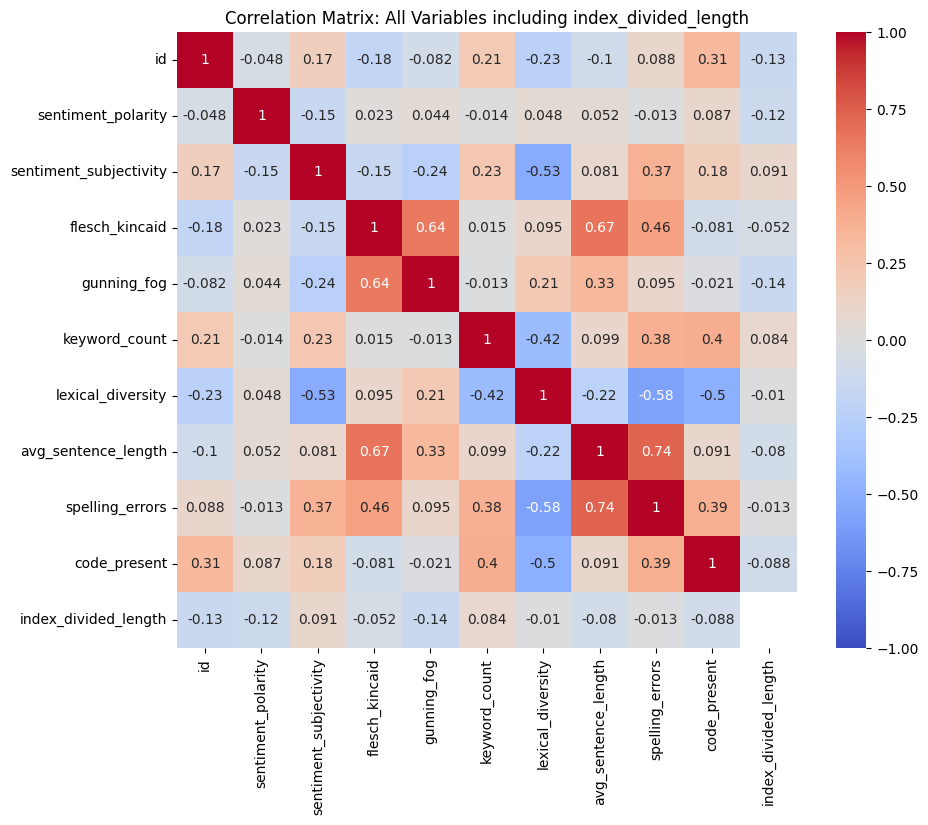

In [13]:
# Calculate correlation matrix for all variables in df
correlation_matrix_all = df.corr()

# Convert index_divided_length to a pandas Series
index_divided_length_series = pd.Series(index_divided_length, name='index_divided_length')

# Calculate correlation between index_divided_length and other variables
correlation_with_index = df.apply(lambda col: col.corr(index_divided_length_series))

# Add index_divided_length correlations to the main correlation matrix
correlation_matrix_all['index_divided_length'] = correlation_with_index
correlation_matrix_all.loc['index_divided_length'] = correlation_with_index

# Display the correlation matrix
print("Correlation matrix:")
print(correlation_matrix_all)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix: All Variables including index_divided_length')
plt.show()

# Conclusion

Sur toutes les métriques présenté ici, la qualité d'une issue n'est pas représentative de la précision des résultats d'un LLM